In [56]:
# Imports
import copy
import torch
import torch.nn as nn
from typing import Union
from torch.utils.data import DataLoader, Dataset
from torchmetrics.classification import Accuracy
from torchmetrics import ConfusionMatrix
from torchvision import datasets, transforms
from torchsummary import summary
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns


In [21]:
# Chargement du jeu de données MNIST
train = datasets.MNIST(
    root="./data",
    download=True,
    train=True,
    transform=transforms.ToTensor(),
)

train_data, val_data, train_targets, val_targets = train_test_split(
    train.data, train.targets,
    test_size=10_000,
    stratify=train.targets,
    random_state=42,
)

validation = copy.deepcopy(train)
validation.data, validation.targets = val_data, val_targets
train.data, train.targets = train_data, train_targets

test = datasets.MNIST(
    root="./data",
    download=True,
    train=False,
    transform=transforms.ToTensor(),
)

print(isinstance(train, Dataset), isinstance(validation, Dataset))
print(len(train), len(validation), len(test))


True True
50000 10000 10000


Train dataset size: 50000
Validation dataset size: 10000
Test dataset size: 10000



Image variable type: <class 'torch.Tensor'>
Image size: torch.Size([1, 28, 28])
Image Label: 7





Train dataset labels: tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
Test dataset labels: tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
Test dataset labels: tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
True
True



Image 1 label: 7


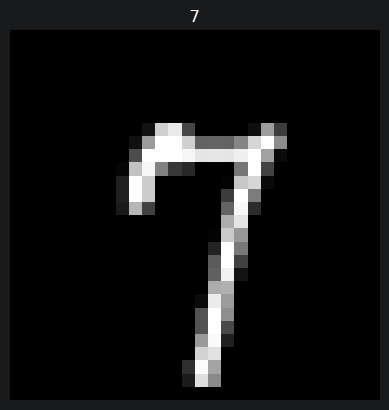

Image 2 label: 1


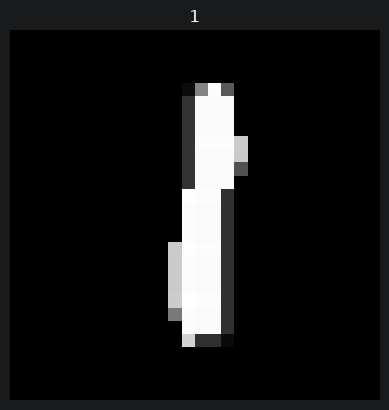

Image 3 label: 9


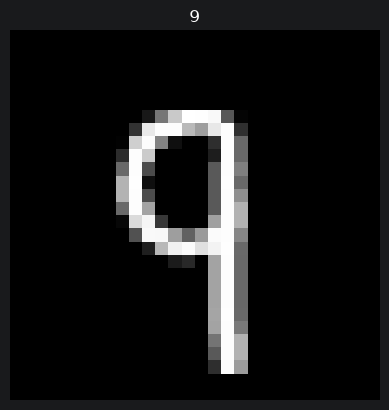




Dataset de validation:  Dataset MNIST
    Number of datapoints: 10000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: ToTensor()



Dataset de test:  Dataset MNIST
    Number of datapoints: 10000
    Root location: ./data
    Split: Test
    StandardTransform
Transform: ToTensor()


In [26]:
# Exploration du jeu de données
print(f"Train dataset size: {len(train)}")
print(f"Validation dataset size: {len(validation)}")
print(f"Test dataset size: {len(test)}")
print("\n"*2)
print("=" * 40)

# Exploration d'un individu
image, label = train[0]
print(f"Image variable type: {type(image)}")
print(f"Image size: {image.shape}")
print(f"Image Label: {label}" + "\n"*2)
print("\n"*2)
print("=" * 40)


# Exploration des labels
print(f"Train dataset labels: {torch.unique(train.targets)}")
print(f"Test dataset labels: {torch.unique(validation.targets)}")
print(f"Test dataset labels: {torch.unique(test.targets)}")
print(torch.equal(torch.unique(train.targets), torch.unique(test.targets)))
print(torch.equal(torch.unique(train.targets), torch.unique(validation.targets)))
print("\n"*2)
print("=" * 40)


# Exploration de quelques individus
for i in range (3):
    image, label = train[i]
    print(f"Image {i+1} label: {label}")
    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(str(label))
    plt.axis('off')
    plt.show()
print("\n"*2)
print("=" * 40)


# Exploration des données de test et de la validation
print("Dataset de validation: ", validation)
print("\n"*2)
print("Dataset de test: ", test)


In [45]:
# Hyperparameters of the model

BATCH_SIZE = 64
LEARNING_RATE = 1e-3
EPOCHS = 5
C1_LAYER_NEURONAL_NUMBER=300

### Construction du CNN

Les images à classer sont de taille $H \times W \times C = 28 \times 28 \times 1$.

Le réseau est constitué de :

* Une couche de convolution $Conv$ avec 10 filtres de taille $K = 5$, stride $S = 1$ et padding *same*.
* Une fonction d'activation ReLU définie par $ReLU(x) = \max(0,x)$.
* Une couche de max pooling avec un noyau $K_p = 2$ et un stride $S_p = 2$.
* Une couche $C_1$ entièrement connectée avec 300 neurones et comme fonction d'activation ReLU.
* Une couche entièrement connectée $C_2$ avec un nombre de neurones adapté à la sortie.
* Une fonction softmax définie par : $softmax(x_j) = \frac{e^{x_j}}{\sum_{i=0}^{n-1}e^{x_i}}$

## a. Taille de la feature map après la couche de convolution $Conv$

La taille de la feature map après passage dans la couche de convolution sera de $28 \times 28$, car le padding est *same*.

On sait que :
$
W_{out} =
\left\lfloor
\frac{W-K+2\times P}{S}
\right\rfloor + 1
$. Avec le padding $P$ étant *same*, on doit avoir : $W_{out}=W=28.$

Ainsi :

$$28 = \frac{28-5+2\times P}{1}+1$$
$$P = \frac{28-24}{2}$$
D'où
$$P=2$$

Comme la couche de convolution contient 10 filtres, elle produit 10 feature maps de taille $28\times28$.

La sortie de la couche de convolution est donc : $\boxed{28\times28\times10}$


## b. Taille de la feature map après la couche de max pooling

Après la couche de max pooling, la taille spatiale de la feature map est : $W_{out}=14.$

En effet, on sait que :
$
W_{out} =
\left\lfloor
\frac{W-K_p+2\times P}{S_p}
\right\rfloor + 1
$. Avec $P=0$.

Ainsi :

$$W_{out} =\frac{28-2+2\times0}{2}+1$$
$$W_{out} =\frac{26}{2}+1$$
$$W_{out}=14$$

La couche de pooling conserve le nombre de canaux. La sortie est donc : $\boxed{14\times14\times10}$


## c. Taille d'entrée de la couche entièrement connectée $C_1$

La couche $C_1$ reçoit en entrée les valeurs obtenues après le max pooling, soit $14\times14\times10=1960$ valeurs.

Avant d'entrer dans la couche entièrement connectée, ces valeurs sont aplaties par une opération de *Flatten* afin d'obtenir un vecteur de taille $1960$.

La couche $C_1$ possède donc :

$$\boxed{1960\text{ entrées}}$$

Pour chacun des 300 neurones de cette couche, on a 1960 poids et un biais.
Le nombre total de paramètres de cette couche est donc : $300\times(1960+1)=588300$.


## d. Nombre de neurones de la couche entièrement connectée $C_2$

La couche $C_2$ contient 10 neurones, car notre jeu de données comporte 10 classes correspondant aux chiffres de $0$ à $9$.
Chaque neurone de sortie correspond, par convention, à une classe :

$$
z_0\leftrightarrow0,\quad
z_1\leftrightarrow1,\quad
\ldots,\quad
z_9\leftrightarrow9.
$$

Les 10 neurones produisent alors 10 scores $(z_0,\ldots,z_9)$ qui seront ensuite transformés en probabilités par la fonction softmax.


In [27]:
# Construction du réseau

# Version séquentielle
conv_layer = nn.Conv2d(
    in_channels=1,
    out_channels=10,
    kernel_size=5,
    stride=1,
    padding="same"
)

relu1 = nn.ReLU()

maxPooling_layer = nn.MaxPool2d(
    kernel_size=2,
    stride=2
)

flatten = nn.Flatten()

c1_layer = nn.Linear(
    in_features=1960,
    out_features=C1_LAYER_NEURONAL_NUMBER
)

relu2 = nn.ReLU()

c2_layer = nn.Linear(
    in_features=C1_LAYER_NEURONAL_NUMBER,
    out_features=10
)

model = nn.Sequential(
    conv_layer,
    relu1,
    maxPooling_layer,
    flatten,
    c1_layer,
    relu2,
    c2_layer
)

summary(model, input_size=(1, 28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 10, 28, 28]             260
              ReLU-2           [-1, 10, 28, 28]               0
         MaxPool2d-3           [-1, 10, 14, 14]               0
           Flatten-4                 [-1, 1960]               0
            Linear-5                  [-1, 300]         588,300
              ReLU-6                  [-1, 300]               0
            Linear-7                   [-1, 10]           3,010
Total params: 591,570
Trainable params: 591,570
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.15
Params size (MB): 2.26
Estimated Total Size (MB): 2.41
----------------------------------------------------------------


### Entraînement du modèle

En entrée, nous aurons des batchs de taille $N=64$ images.

Une époque consistera à entraîner le modèle sur le dataset d'entraînement contenant $D=60,000$ images. Le nombre de batchs par époque est donc :

$$N_{batch} = \frac{D}{N}=\frac{60\,000}{64}=937,5$$

Comme un batch ne peut pas contenir une fraction d'image, cela correspond à **938 batchs**, dont 937 batchs de 64 images et un dernier batch de 32 images.

Les poids du modèle seront mis à jour après le traitement de chaque batch.

Un individu du dataset est noté $(X_i, y_i)$. Donné au modèle, $X_i$ produit un vecteur de scores qui, après application de la fonction softmax, donne une distribution de probabilités :

$$(p_0,p_1,\dots,p_8,p_9)$$

où $p_c$ représente la probabilité prédite que $X_i$ appartienne à la classe $c$.

La fonction de perte mesure alors la qualité de la prédiction du modèle en regardant notamment la probabilité qu'il a attribuée à la classe réellement observée $y_i$.

Pour une observation $X_i$ dont la classe réelle est $y_i$, la cross entropy est donnée par :

$$\boxed{\mathcal{L}_i=-\log(p_{y_i})}$$

Ainsi, si l'image $X_i$ représente par exemple le chiffre $3$, alors $y_i=3$ et la perte vaut :

$$\mathcal{L}_i=-\log(p_3)$$

Plus le modèle attribue une forte probabilité à la classe réelle, plus la perte est faible. À l'inverse, si le modèle attribue une très faible probabilité à la classe réelle, la perte devient importante.

Pour un batch donc, la cross-entropy est la moyenne des pertes sur les images qu'il contient, soit :

$$
\boxed{
\mathcal{L}_{batch}
=
\frac{1}{N}
\sum_{i=1}^{N}
\mathcal{L}_i
}
$$


On obtient donc :

$$
\boxed{
\mathcal{L}_{batch}
=
-\frac{1}{N}
\sum_{i=1}^{N}
\log(p_{y_i})
}
$$

avec $N=64$ pour notre batch.

La valeur obtenue représente ainsi la perte moyenne du modèle sur l'ensemble des 64 images du batch.


### Rétropropagation

Une fois la perte du batch calculée, le modèle doit déterminer comment modifier ses poids afin de réduire cette perte.

On cherche donc les paramètres $W$ qui minimisent la fonction de perte :

$$
\boxed{
W^*=\arg\min_W \mathcal{L}_{batch}(W)
}
$$

Pour savoir dans quelle direction modifier les poids, on calcule le gradient de la fonction de perte par rapport aux paramètres du modèle :

$$
\boxed{
\nabla_W \mathcal{L}_{batch}
}
$$

Ce gradient contient, pour chaque paramètre, l'information sur la variation locale de la perte lorsque ce paramètre varie.

La rétropropagation (*backpropagation*) permet de calculer efficacement ce gradient en appliquant la règle de dérivation en chaîne à travers les différentes opérations du réseau, en remontant depuis la fonction de perte jusqu'aux premières couches.

Pour un paramètre $w$, on obtient par exemple :

$$
\frac{\partial \mathcal{L}_{batch}}{\partial w}
$$

Si cette dérivée est positive, une augmentation locale de $w$ entraîne une augmentation de la perte. À l'inverse, si elle est négative, une augmentation locale de $w$ entraîne une diminution de la perte.

Le gradient indique donc localement la direction dans laquelle la fonction de perte augmente le plus rapidement. Pour minimiser la perte, l'optimisation doit donc se déplacer dans la direction opposée au gradient.

### Mise à jour des poids avec Adam

Une descente de gradient classique mettrait à jour les paramètres selon :

$$
\boxed{
W_{t+1}
=
W_t-\eta\nabla_W\mathcal{L}_t
}
$$

où $\eta$ représente le taux d'apprentissage (*learning rate*).

Dans notre modèle, nous utilisons cependant l'optimiseur **Adam** (*Adaptive Moment Estimation*).

Adam utilise le gradient calculé par rétropropagation, mais conserve également une information sur les gradients des itérations précédentes afin d'adapter la mise à jour des paramètres.

Pour chaque paramètre, Adam maintient deux quantités :

* un premier moment $m_t$, qui correspond à une moyenne exponentiellement pondérée des gradients ;
* un second moment $v_t$, qui correspond à une moyenne exponentiellement pondérée des carrés des gradients.

Le premier moment est mis à jour selon :

$$
\boxed{
m_t
=
\beta_1m_{t-1}
+
(1-\beta_1)g_t
}
$$

où

$$
g_t=\nabla_W\mathcal{L}_t
$$

est le gradient calculé à l'itération $t$.

Le paramètre $\beta_1$ contrôle l'importance accordée à l'historique des gradients. Avec la valeur couramment utilisée $\beta_1=0.9$, le nouvel état $m_t$ conserve fortement l'information précédente tout en intégrant le gradient courant.

Le second moment est mis à jour selon :

$$
\boxed{
v_t
=
\beta_2v_{t-1}
+
(1-\beta_2)g_t^2
}
$$

Le terme $g_t^2$ représente le carré du gradient, calculé paramètre par paramètre. Cette quantité permet à Adam de tenir compte de l'échelle des gradients.

Adam applique ensuite une correction de biais aux deux moments :

$$
\boxed{
\hat m_t=\frac{m_t}{1-\beta_1^t}
}
$$

et

$$
\boxed{
\hat v_t=\frac{v_t}{1-\beta_2^t}
}
$$

Les paramètres sont finalement mis à jour selon :

$$
\boxed{
W_{t+1}
=
W_t
-
\eta
\frac{\hat m_t}
{\sqrt{\hat v_t}+\varepsilon}
}
$$

où $\varepsilon$ est une petite constante permettant notamment d'éviter une division par zéro.

Ainsi, pour chaque batch, le processus d'entraînement peut être résumé par :

$$
\boxed{
\text{Batch}
\rightarrow
\text{prédictions}
\rightarrow
\text{loss}
\rightarrow
\text{backpropagation}
\rightarrow
\text{gradient}
\rightarrow
\text{Adam}
\rightarrow
\text{nouveaux poids}
}
$$

Les nouveaux poids sont ensuite utilisés pour traiter le batch suivant. Le processus est répété pour l'ensemble des batchs de l'époque, puis pour les époques suivantes.




In [28]:
#Entrainement du modèle en version séquentielle

# Batchs du datasets de 64 images par batch
train_batch = DataLoader(
    dataset=train,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

# Fonction de perte (négative de la log-vraisemblance)
loss_function = nn.CrossEntropyLoss()

# Optimiseur permettant la mise à jour des poids
optimizer = torch.optim.Adam(
    params=model.parameters(),
    lr=LEARNING_RATE
)

model.train()

# Entrainement effectif pour le nombre d'époques.
for epoch in range (EPOCHS):
    for X_batch, y_batch in train_batch:
        optimizer.zero_grad()
        output = model(X_batch)
        loss = loss_function(output, y_batch)
        loss.backward()
        optimizer.step()




In [32]:
# Tests et mésures
test_batch = DataLoader(
    dataset=test,
    batch_size=BATCH_SIZE,
    shuffle=False
)

model.eval()

correct = 0
total = len(test_target)

with torch.no_grad():
    for X_batch, y_batch in test_batch:
        output = model(X_batch)
        prediction = output.argmax(dim=1)
        correct += (prediction == y_batch).sum().item()

accuracy = correct/total
print(accuracy)

0.9797


In [44]:
# Version Orientée objet
class CNN(nn.Module):

    def __init__(self):
        super().__init__()

        # Architecture du réseau
        self.conv_layer = nn.Conv2d(
            in_channels=1,
            out_channels=10,
            kernel_size=5,
            padding="same",
            stride=1
        )
        self.relu1 = nn.ReLU()
        self.maxPooling_layer = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )
        self.flatten = nn.Flatten()
        self.c1_layer = nn.Linear(
            in_features=1960,
            out_features=C1_LAYER_NEURONAL_NUMBER
        )
        self.relu2 = nn.ReLU()
        self.c2_layer = nn.Linear(
            in_features=C1_LAYER_NEURONAL_NUMBER,
            out_features=10
        )

        # Fonction de perte
        self.loss_function = nn.CrossEntropyLoss()

        # Optimiseur
        self.optimizer = torch.optim.Adam(
            self.parameters(),
            lr=LEARNING_RATE
        )

        # Historique de la loss
        self.losses = []
        self.epoch_boundaries = []

        # Historique de la validation (mesurée tous les N steps)
        self.validation_steps = []
        self.validation_losses = []
        self.validation_accuracies = []
        self.mean_loss_per_step = []


    def forward(self, x):
        filtered_x = self.maxPooling_layer(self.relu1(self.conv_layer(x)))
        flat_x = self.flatten(filtered_x)
        mlp_x = self.relu2(self.c1_layer(flat_x))
        return self.c2_layer(mlp_x)


    def show_summary(self):
        summary(self, input_size=(1, 28, 28))


    def _validation_metrics(self, validation, batch_size):
        loader = DataLoader(
            dataset=validation,
            batch_size=batch_size,
            shuffle=False
        )

        self.eval()
        total_loss = 0.0
        correct = 0

        with torch.no_grad():
            for X_batch, y_batch in loader:
                output = self(X_batch)
                total_loss += self.loss_function(output, y_batch).item() * len(y_batch)
                correct += (output.argmax(dim=1) == y_batch).sum().item()
        self.train()
        return total_loss / len(validation), correct / len(validation)


    def fit(self, train_data, epochs, batch_size, validation_data=None, eval_every=100):
        train_batch = DataLoader(
            dataset=train_data,
            batch_size=batch_size,
            shuffle=True
        )

        self.train()
        step = 0

        # Entrainement effectif pour le nombre d'époques.
        for epoch in range(epochs):

            for X_batch, y_batch in train_batch:
                self.optimizer.zero_grad()
                output = self(X_batch)
                loss = self.loss_function(output, y_batch)
                loss.backward()
                self.optimizer.step()

                # On conserve la loss de chaque batch
                self.losses.append(loss.item())
                step += 1  # NOUVEAU

                # NOUVEAU : contrôle sur la validation tous les eval_every steps
                if validation_data is not None and step % eval_every == 0:
                    self.mean_loss_per_step.append(sum(self.losses[-eval_every:]) / eval_every)
                    validation_loss, validation_acc = self._validation_metrics(validation_data, batch_size)
                    self.validation_steps.append(step)
                    self.validation_losses.append(validation_loss)
                    self.validation_accuracies.append(validation_acc)

            # Position du passage à l'époque suivante
            if epoch < epochs - 1:
                self.epoch_boundaries.append(len(self.losses))


    def plot_loss(self, show_validation=True):
        plt.figure(figsize=(10, 5))

        if show_validation and self.validation_losses:
            plt.plot(self.validation_steps, self.mean_loss_per_step, "o-", label="Train (moyenne)")
            plt.plot(self.validation_steps, self.validation_losses, "o-", label="Validation")
        else:
            plt.plot(range(1, len(self.losses) + 1), self.losses, label="Train")

        for boundary in self.epoch_boundaries:
            plt.axvline(x=boundary, linestyle="--", color="gray", alpha=0.5)

        plt.xlabel("Step (batch)")
        plt.ylabel("Loss")
        plt.title("Évolution de la loss pendant l'entraînement")
        plt.legend()
        plt.show()


    def plot_accuracy(self):
        plt.figure(figsize=(10, 5))

        plt.plot(self.validation_steps, self.validation_accuracies, "o-", label="Validation")

        for boundary in self.epoch_boundaries:
            plt.axvline(x=boundary, linestyle="--", color="gray", alpha=0.5)

        plt.xlabel("Step (batch)")
        plt.ylabel("Accuracy")
        plt.title("Évolution de l'accuracy sur la validation")
        plt.legend()
        plt.show()


    def evaluate(self, data, batch_size):

        y_pred = []
        y_true = []
        proba_distribution = []
        test_batch = DataLoader(
            dataset=data,
            batch_size=batch_size,
            shuffle=False
        )

        self.eval()

        with torch.no_grad():

            for X_batch, y_batch in test_batch:
                model_output = self(X_batch)
                y_pred.append(model_output.argmax(dim=1))
                y_true.append(y_batch)
                proba_distribution.append(torch.softmax(model_output, dim=1))

        y_pred = torch.cat(y_pred)
        y_true = torch.cat(y_true)
        proba_distribution = torch.cat(proba_distribution)
        return y_pred, y_true, proba_distribution




    def accuracy(self, data, batch_size):
        y_pred, y_true, _ = self.evaluate(data, batch_size)
        correct = (y_pred == y_true).sum().item()
        total = len(y_true)
        return correct / total


    def score(self, data, batch_size, scoring):
        y_pred, y_true, proba_distribution = self.evaluate(data, batch_size)

        match scoring:
            case "accuracy":
                metric = Accuracy(task="multiclass", num_classes=10)
                return metric(y_pred, y_true).item()

        raise ValueError(f"Métrique inconnue : {scoring}")

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 10, 28, 28]             260
              ReLU-2           [-1, 10, 28, 28]               0
         MaxPool2d-3           [-1, 10, 14, 14]               0
           Flatten-4                 [-1, 1960]               0
            Linear-5                  [-1, 300]         588,300
              ReLU-6                  [-1, 300]               0
            Linear-7                   [-1, 10]           3,010
Total params: 591,570
Trainable params: 591,570
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.15
Params size (MB): 2.26
Estimated Total Size (MB): 2.41
----------------------------------------------------------------


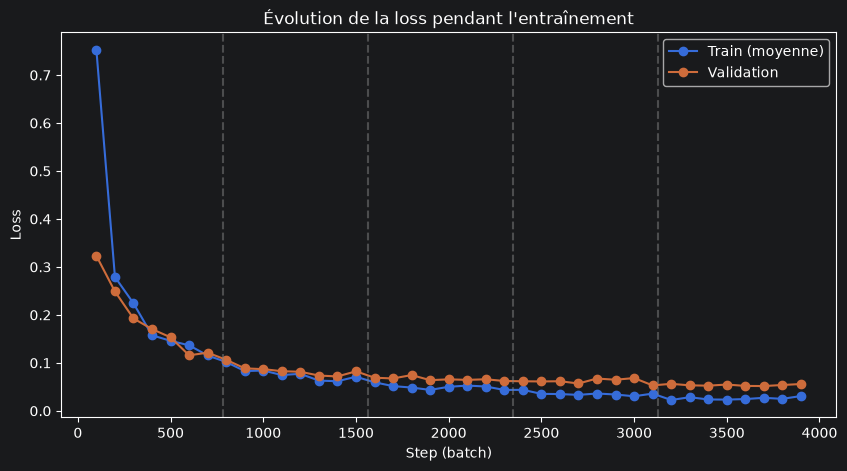

Précision du modèle 0.9806


In [46]:
cnn = CNN()
cnn.show_summary()
cnn.fit(
    train_data=train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=validation,
)
cnn.plot_loss()
print("Précision du modèle", cnn.accuracy(test, BATCH_SIZE))

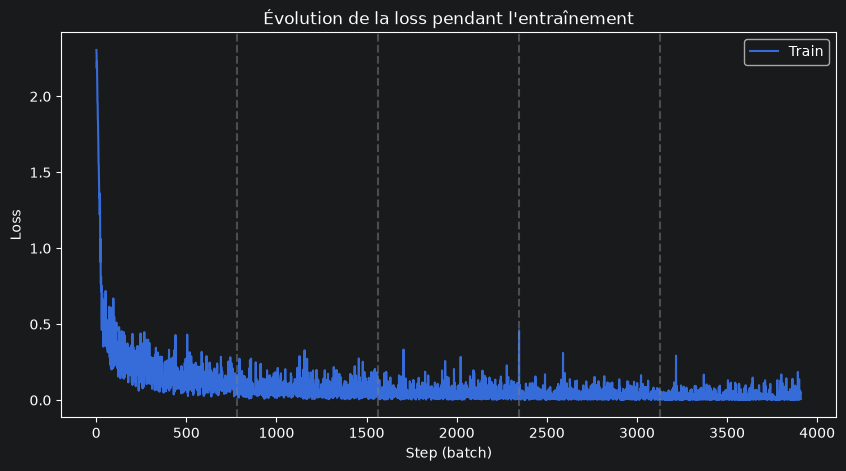

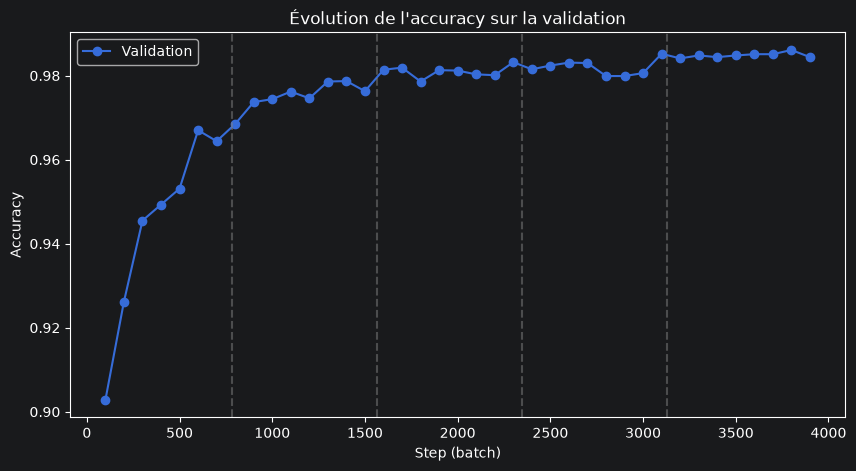

In [47]:
cnn.plot_loss(show_validation=False)
cnn.plot_accuracy()

### Amélioration du modèle

# Dropout

On souhaite que le modèle dépende moins de certains neurones pour apprendre (on évite la *co-adaptation* : des neurones qui se reposent les uns sur les autres). On éteint donc, pendant l'entraînement et sur certaines couches, des neurones choisis aléatoirement. Le modèle est ainsi forcé d'apprendre des représentations robustes, et il sur-apprend moins.

Le *taux de dropout*, noté $p$, désigne la probabilité qu'un neurone soit désactivé pendant l'entraînement. En moyenne, une proportion $p$ des neurones de la couche est éteinte à chaque passage. On note $q = 1 - p$ la probabilité de garder un neurone.

## Le masque

Un masque est appliqué **après l'activation** d'une couche. Pour une couche de $n$ neurones d'activations $h_1, \dots, h_n$, on tire pour chaque neurone, indépendamment :

$$
m_i \sim \text{Bernoulli}(q), \qquad m_i \in \{0, 1\}
$$

- $m_i = 1$ : le neurone est conservé
- $m_i = 0$ : le neurone est éteint

 Les tirages sont indépendants. Le nombre de neurones conservés suit une loi Binomiale\((n,q)\) et vaut \(nq\) en moyenne. Le nombre de neurones désactivés suit une loi Binomiale\((n,p)\) et vaut \(np\) en moyenne. Un nouveau masque est tiré à chaque forward pass, indépendamment pour chaque couche.

## Compensation d'échelle (inverted dropout)

Comme $\mathbb{E}[m_i] = q$, le masque multiplie le signal moyen par $q$. À l'évaluation, tous les neurones sont actifs, et la couche suivante recevrait alors des signaux d'une échelle différente de celle vue à l'entraînement.

Pour l'éviter, on **divise par $q$** les activations conservées, dès l'entraînement :

$$
\tilde{h}_i = \frac{m_i \, h_i}{q}
$$

Ainsi, $\mathbb{E}[\tilde{h}_i] = \dfrac{q \, h_i}{q} = h_i$ : en moyenne, l'entraînement et l'évaluation ont la même échelle.


## Évaluation (test, inférence)

Le dropout est **désactivé** : $\tilde{\mathbf{h}} = \mathbf{h}$, sans masque ni division. La compensation ayant déjà été faite à l'entraînement, le code d'inférence est identique à celui d'un réseau sans dropout.


# BatchNorm

La distribution d'entrée d'une couche (les activations de la couche précédente) bouge sans cesse (l'échelle des valeurs varie d'une couche à une autre) pendant l'apprentissage. La batch normalization stabilise ces activations, en appliquant une normalisation par rapport à la moyenne et l'écart type des activations, et de façon adaptative.

Concrètement, c'est une couche à part entière, placée entre une couche de neurones et la fonction d'activation. Elle normalise les **sommations** $z = Wx + b$ (avant activation), neurone par neurone, à travers les exemples du mini-batch.

## Outils : moyenne et écart-type

Une liste de nombres est décrite par deux valeurs : sa moyenne $\mu$ (où elle est centrée) et son écart-type $\sigma$ (de combien elle est étalée).

$$
\mu = \frac{1}{m}\sum_{i=1}^{m} z^{(i)}, \qquad \sigma^2 = \frac{1}{m}\sum_{i=1}^{m}\left(z^{(i)} - \mu\right)^2, \qquad \sigma = \sqrt{\sigma^2}
$$

Effet de deux transformations simples sur une liste $z$ :

| Transformation            | Moyenne   | Écart-type               |
|---------------------------|-----------|--------------------------|
| Ajouter une constante $c$ | $\mu + c$ | $\sigma$ (inchangé)      |
| Multiplier par $a$        | $a\,\mu$  | $\lvert a\rvert\,\sigma$ |

Donc $y = a\,z + c$ a pour moyenne $a\mu + c$ et pour écart-type $\lvert a\rvert\sigma$. Ajouter déplace le centre sans toucher à l'étalement, multiplier agit sur les deux.

## Normalisation

Dans un mini-batch de $m$ exemples, un neurone $k$ produit une valeur par exemple : $z_k^{(1)}, \dots, z_k^{(m)}$. Chaque exemple traverse la couche indépendamment, avec les mêmes poids, et c'est seulement le calcul des statistiques qui mélange les exemples.

On lit le batch comme un tableau : **une colonne par neurone, une ligne par exemple**. Les statistiques sont calculées **sur chaque colonne**, séparément :

$$
\mu_k = \frac{1}{m}\sum_{i=1}^{m} z_k^{(i)}, \qquad \sigma_k^2 = \frac{1}{m}\sum_{i=1}^{m}\left(z_k^{(i)} - \mu_k\right)^2
$$

Puis on normalise, en deux gestes dans cet ordre : recentrer (ajouter $-\mu_k$), puis rééchelonner (multiplier par $\frac{1}{\sigma_k}$) :

$$
\hat{z}_k^{(i)} = \frac{z_k^{(i)} - \mu_k}{\sqrt{\sigma_k^2 + \epsilon}}
$$

- $\hat z_k$ a une moyenne de $0$ et un écart-type de $1$ sur le batch.
- $\epsilon$ (par exemple $10^{-5}$) évite une division par zéro.
- La normalisation **efface l'échelle d'entrée** : $\frac{10z - 10\mu}{10\sigma} = \frac{z-\mu}{\sigma}$. Peu importe l'échelle produite par les couches précédentes, la couche suivante voit toujours la même distribution.
- $\mu_k$ et $\sigma_k$ sont **calculés** à chaque batch, ils ne sont pas appris.

## Paramètres appris $\gamma$ et $\beta$

Forcer systématiquement $(0, 1)$ retire au réseau la liberté de choisir le centre et l'étalement qui lui conviennent. On redonne donc les deux mêmes gestes, mais **réglés par le réseau** :

$$
y_k^{(i)} = \gamma_k\,\hat{z}_k^{(i)} + \beta_k
$$

D'après le tableau des transformations, $y_k$ a pour moyenne $\beta_k$ et pour écart-type $\lvert\gamma_k\rvert$ :

- $\beta_k$ règle le **centre** du neurone $k$
- $\gamma_k$ règle son **étalement**

Propriétés :
- $\gamma_k$ et $\beta_k$ sont des **paramètres du neurone $k$**, appris par descente de gradient comme les poids. Initialisation : $\gamma = 1$, $\beta = 0$ (au départ, la sortie est la normalisation brute).
- Il y a **un couple par neurone** : pour une couche de $n$ neurones, $2n$ paramètres, quelle que soit la taille du batch.
- Un même couple $(\gamma_k, \beta_k)$ sert pour **tous les exemples** du batch, comme les poids $W_k$.


### Gradients de $\gamma$ et $\beta$

Comme $\gamma_k$ et $\beta_k$ sont partagés par les $m$ exemples, leurs gradients sont des **sommes** sur le batch (règle de la chaîne : une variable qui influence plusieurs sorties reçoit la somme des contributions) :

$$
\frac{\partial L}{\partial \beta_k} = \sum_{i=1}^{m}\frac{\partial L}{\partial y_k^{(i)}}, \qquad \frac{\partial L}{\partial \gamma_k} = \sum_{i=1}^{m}\frac{\partial L}{\partial y_k^{(i)}}\,\hat{z}_k^{(i)}
$$

Mise à jour : $\gamma_k \leftarrow \gamma_k - \eta\,\dfrac{\partial L}{\partial \gamma_k}$ et $\beta_k \leftarrow \beta_k - \eta\,\dfrac{\partial L}{\partial \beta_k}$. Si la loss est une moyenne sur le batch, le facteur $\frac{1}{m}$ est déjà contenu dans $\frac{\partial L}{\partial y_k^{(i)}}$, il ne faut pas le rajouter.

## Entraînement vs évaluation

**Entraînement** : la normalisation utilise $\mu_k, \sigma_k^2$ du batch courant. En parallèle, on accumule des moyennes mobiles exponentielles des statistiques globales. Elles ne sont pas apprises par gradient et ne servent pas à normaliser à ce moment-là :

$$
\mu_{\text{run}} \leftarrow \alpha\,\mu_{\text{run}} + (1-\alpha)\,\mu_k, \qquad \sigma^2_{\text{run}} \leftarrow \alpha\,\sigma^2_{\text{run}} + (1-\alpha)\,\sigma_k^2
$$

avec $\alpha$ proche de $1$ (par exemple $0.9$). Cette mémoire oublie progressivement le passé, donc elle reste représentative de l'état récent du réseau.

**Évaluation** : on ne peut pas utiliser les statistiques d'un batch (un exemple isolé n'a pas de batch, et une prédiction doit être déterministe et indépendante des autres exemples). On utilise **uniquement** les statistiques figées à la fin de l'entraînement, avec les $\gamma$ et $\beta$ appris :

$$
\hat{z} = \frac{z - \mu_{\text{run}}}{\sqrt{\sigma^2_{\text{run}} + \epsilon}}, \qquad y = \gamma\,\hat{z} + \beta
$$



In [57]:
class ConvolutionBlock(nn.Module):

    def __init__(self, input_shape: tuple, n_filters: int, kernel_size: int, padding: Union[str, int] = "same", stride: int = 1, use_batch_norm: bool = False, pool_kernel_size: int = 2, pool_stride: int = 2, pool_padding: int = 0, dropout_rate: float = 0.0 ):

        super().__init__()

        self.input_shape = input_shape
        self.n_filters = n_filters
        self.kernel_size = kernel_size
        self.conv_padding = padding
        self.conv_stride = stride
        self.pooling_kernel_size = pool_kernel_size
        self.pooling_stride = pool_stride
        self.pooling_padding = pool_padding

        self.conv = nn.Conv2d(
            in_channels= input_shape[0],
            out_channels= n_filters,
            kernel_size=kernel_size,
            padding=padding,
            stride=stride,
        )

        self.batch_norm = nn.BatchNorm2d(
            num_features=n_filters,
        ) if use_batch_norm else None

        self.activation = nn.ReLU()
        self.dropout = nn.Dropout(p=dropout_rate)
        self.pool = nn.MaxPool2d(
            kernel_size=pool_kernel_size,
            stride=pool_stride,
            padding=pool_padding,
        )


    def forward(self, X) :
        output = self.conv(X)
        if self.batch_norm is not None:
            output = self.batch_norm(output)
        output = self.activation(output)
        output = self.pool(output)
        return self.dropout(output)


    def output_shape(self):
        height = self.input_shape[1]
        width = self.input_shape[2]

        if self.conv_padding == "same":
            height_before_pooling = height
            width_before_pooling = width
        else:
            assert isinstance(self.conv_padding, int)
            height_before_pooling =  (height - self.kernel_size + 2 * self.conv_padding) // self.conv_stride + 1
            width_before_pooling = (width - self.kernel_size + 2 * self.conv_padding) // self.conv_stride + 1

        height_after_pooling: int = (height_before_pooling - self.pooling_kernel_size + 2 * self.pooling_padding) // self.pooling_stride + 1
        width_after_pooling: int = (width_before_pooling - self.pooling_kernel_size + 2 * self.pooling_padding) // self.pooling_stride + 1

        return self.n_filters, height_after_pooling, width_after_pooling

    def n_pixels(self) -> int:
        shape = self.output_shape()
        return shape[0] * shape[1] * shape[2]



class ExperimentalCNN(nn.Module):
    def __init__(self, convolutions: nn.ModuleList, n_neural_layer: int, n_labels: int , learning_rate: float):
        super().__init__()

        self.conv_blocks = convolutions
        self.n_labels = n_labels

        # Historique de la loss
        self.losses = []
        self.epoch_boundaries = []

        # Historique de la validation (mesurée tous les N batchs)
        self.validation_steps = []
        self.validation_losses = []
        self.validation_accuracies = []
        self.mean_loss_per_step = []

        self.flatten = nn.Flatten()
        self.linear = nn.Linear(
            in_features=self.conv_blocks[-1].n_pixels(),
            out_features=n_neural_layer,
        )
        self.out_layer = nn.Linear(
            in_features=n_neural_layer,
            out_features=n_labels,
        )
        self.activation = nn.ReLU()


        self.loss_function = nn.CrossEntropyLoss()
        self.optimizer = torch.optim.Adam(
            params=self.parameters(),
            lr=learning_rate,
        )

    def forward(self, X):
        for convolution in self.conv_blocks:
            X = convolution(X)
        output = self.flatten(X)
        output = self.linear(output)
        output = self.activation(output)
        return self.out_layer(output)


    def _validation_metrics(self, validation, batch_size):
        loader = DataLoader(
            dataset=validation,
            batch_size=batch_size,
            shuffle=False
        )

        self.eval()
        total_loss = 0.0
        correct = 0

        with torch.no_grad():
            for X_batch, y_batch in loader:
                output = self(X_batch)
                total_loss += self.loss_function(output, y_batch).item() * len(y_batch)
                correct += (output.argmax(dim=1) == y_batch).sum().item()

        self.train()
        return total_loss / len(validation), correct / len(validation)


    def fit(self, train_data, epochs, batch_size, validation_data=None, eval_every=100):
        train_batch = DataLoader(
            dataset=train_data,
            batch_size=batch_size,
            shuffle=True
        )

        self.train()
        step = 0

        for epoch in range(epochs):
            for X_batch, y_batch in train_batch:
                self.optimizer.zero_grad()
                loss = self.loss_function(self(X_batch), y_batch)
                loss.backward()
                self.optimizer.step()

                # On conserve la loss de chaque batch
                self.losses.append(loss.item())
                step += 1

                # Contrôle sur la validation tous les eval_every steps
                if validation_data is not None and step % eval_every == 0:
                    self.mean_loss_per_step.append(sum(self.losses[-eval_every:]) / eval_every)
                    validation_loss, validation_acc = self._validation_metrics(validation_data, batch_size)
                    self.validation_steps.append(step)
                    self.validation_losses.append(validation_loss)
                    self.validation_accuracies.append(validation_acc)

            # Position du passage à l'époque suivante
            if epoch < epochs - 1:
                self.epoch_boundaries.append(len(self.losses))


    def evaluate(self, data, batch_size):
        loader = DataLoader(
            dataset=data,
            batch_size=batch_size,
            shuffle=False
        )
        y_pred, y_true, probas = [], [], []
        self.eval()
        with torch.no_grad():
            for X, y in loader:
                out = self(X)
                y_pred.append(out.argmax(dim=1))
                y_true.append(y)
                probas.append(torch.softmax(out, dim=1))
        return torch.cat(y_pred), torch.cat(y_true), torch.cat(probas)


    def plot_loss(self, show_validation=True):
        plt.figure(figsize=(10, 5))

        if show_validation and self.validation_losses:
            plt.plot(self.validation_steps, self.mean_loss_per_step, "o-", label="Train (moyenne)")
            plt.plot(self.validation_steps, self.validation_losses, "o-", label="Validation")
        else:
            plt.plot(range(1, len(self.losses) + 1), self.losses, label="Train")

        for boundary in self.epoch_boundaries:
            plt.axvline(x=boundary, linestyle="--", color="gray", alpha=0.5)

        plt.xlabel("Step (batch)")
        plt.ylabel("Loss")
        plt.title("Évolution de la loss pendant l'entraînement")
        plt.legend()
        plt.show()


    def plot_accuracy(self):
        plt.figure(figsize=(10, 5))
        plt.plot(self.validation_steps, self.validation_accuracies, "o-", label="Validation")

        for boundary in self.epoch_boundaries:
            plt.axvline(x=boundary, linestyle="--", color="gray", alpha=0.5)

        plt.xlabel("Step (batch)")
        plt.ylabel("Accuracy")
        plt.title("Évolution de l'accuracy sur la validation")
        plt.legend()
        plt.show()


    def score(self, data, batch_size, scoring="accuracy"):
        y_pred, y_true, _ = self.evaluate(data, batch_size)

        match scoring:
            case "accuracy":
                metric = Accuracy(task="multiclass", num_classes=self.n_labels)
                return metric(y_pred, y_true).item()

            case "confusion_matrix":
                metric = ConfusionMatrix(task="multiclass", num_classes=self.n_labels)
                matrix = metric(y_pred, y_true)

                plt.figure(figsize=(8, 6))
                sns.heatmap(matrix.numpy(), annot=True, fmt="d", cmap="Blues")
                plt.xlabel("Prédiction")
                plt.ylabel("Vrai label")
                plt.title("Matrice de confusion")
                plt.show()
                return matrix

        raise ValueError(f"Métrique inconnue : {scoring}")


    def show_summary(self):
        summary(self, input_size=self.conv_blocks[0].input_shape)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 10, 28, 28]             260
              ReLU-2           [-1, 10, 28, 28]               0
         MaxPool2d-3           [-1, 10, 14, 14]               0
           Dropout-4           [-1, 10, 14, 14]               0
  ConvolutionBlock-5           [-1, 10, 14, 14]               0
           Flatten-6                 [-1, 1960]               0
            Linear-7                  [-1, 300]         588,300
              ReLU-8                  [-1, 300]               0
            Linear-9                   [-1, 10]           3,010
Total params: 591,570
Trainable params: 591,570
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.18
Params size (MB): 2.26
Estimated Total Size (MB): 2.44
-------------------------------------------

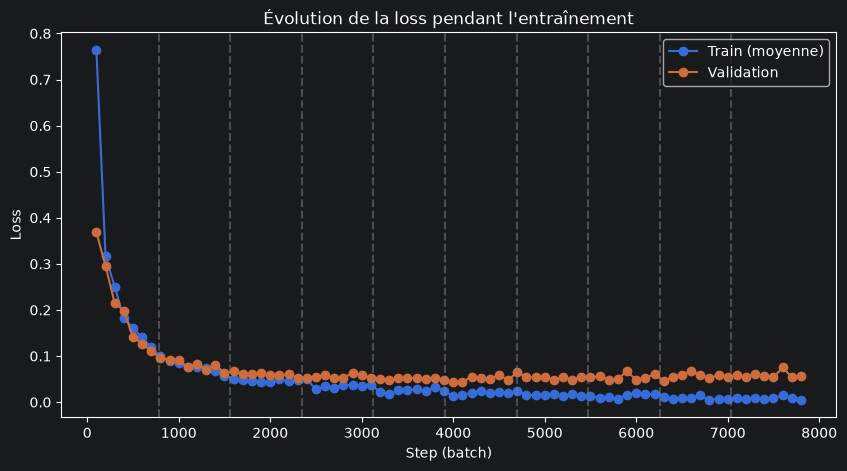

0.986299991607666


In [49]:
# Construction des expérimentations

conv_bloc = ConvolutionBlock(
    input_shape=(1, 28, 28),
    n_filters=10,
    kernel_size=5,
)

proof = ExperimentalCNN(
    convolutions=nn.ModuleList([conv_bloc]),
    n_neural_layer=300,
    n_labels=len(train.targets.unique()),
    learning_rate=LEARNING_RATE
)

proof.show_summary()
proof.fit(
    train_data=train,
    epochs=10,
    batch_size=BATCH_SIZE,
    validation_data=validation,
)
proof.plot_loss()
print(proof.score(test, BATCH_SIZE, scoring="accuracy"))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 10, 28, 28]             100
       BatchNorm2d-2           [-1, 10, 28, 28]              20
              ReLU-3           [-1, 10, 28, 28]               0
         MaxPool2d-4           [-1, 10, 14, 14]               0
           Dropout-5           [-1, 10, 14, 14]               0
  ConvolutionBlock-6           [-1, 10, 14, 14]               0
            Conv2d-7           [-1, 20, 14, 14]           1,820
       BatchNorm2d-8           [-1, 20, 14, 14]              40
              ReLU-9           [-1, 20, 14, 14]               0
        MaxPool2d-10             [-1, 20, 7, 7]               0
          Dropout-11             [-1, 20, 7, 7]               0
 ConvolutionBlock-12             [-1, 20, 7, 7]               0
           Conv2d-13             [-1, 30, 7, 7]           5,430
      BatchNorm2d-14             [-1, 3

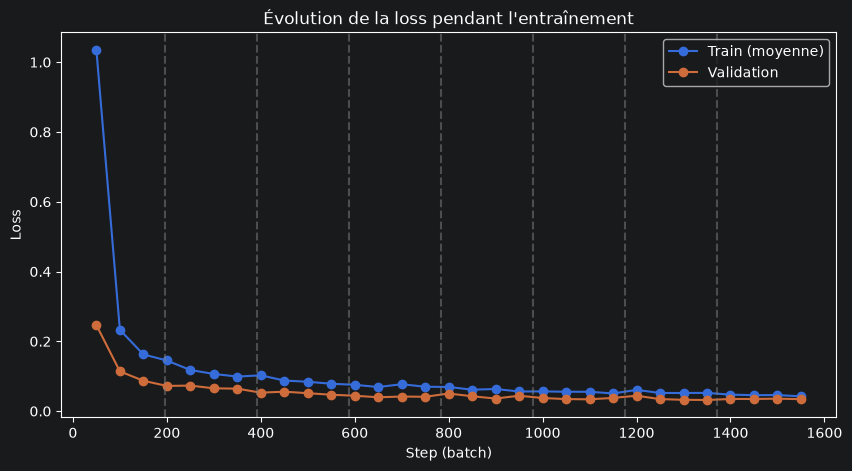

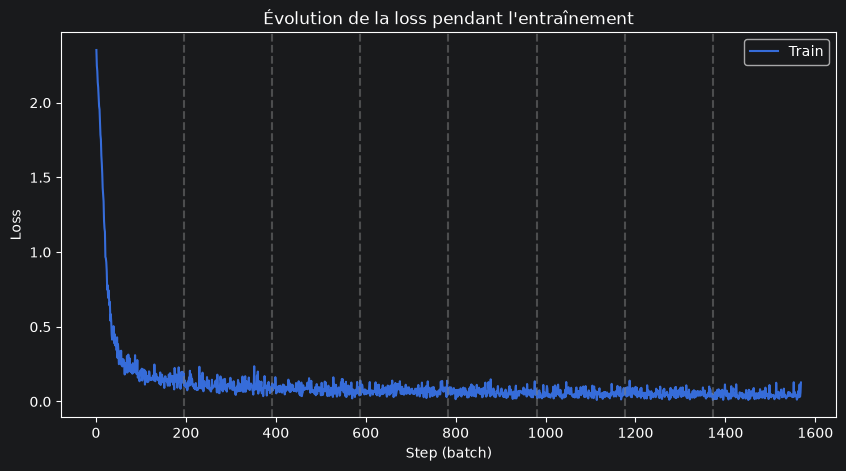

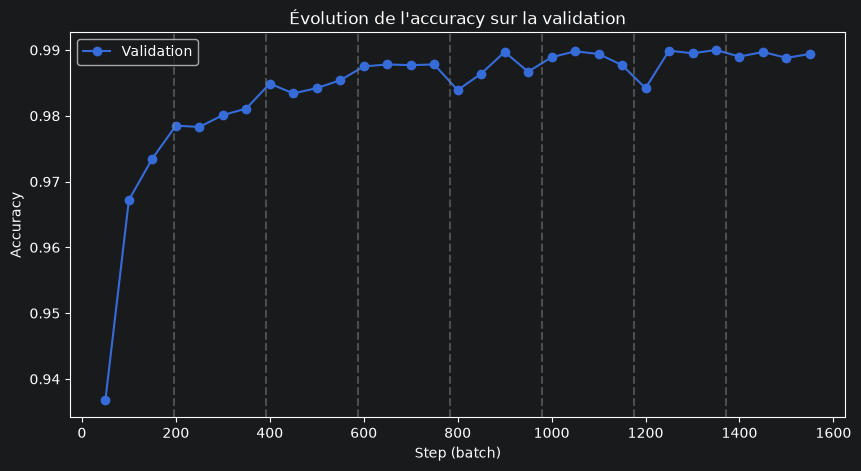

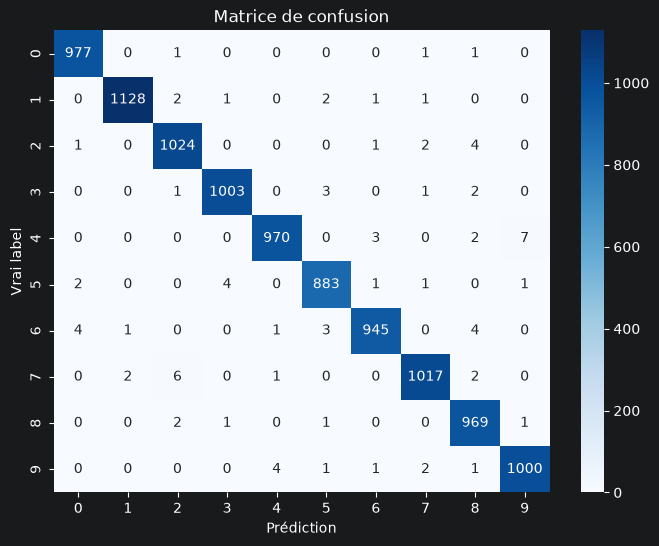

La précision de l'expérience 1 est de:  0.991599977016449


In [58]:
# 1. Augmenter le nombre de filtres, de couche de convolution, rajouter du dropout et rajouter des couches de batch normalization, varier la taille des batchs (64, 128 et 256)
conv_bloc_1 = ConvolutionBlock(
    input_shape=(1, 28, 28),
    n_filters=10,
    kernel_size=3,
    use_batch_norm=True,
)
conv_bloc_2 = ConvolutionBlock(
    input_shape=conv_bloc_1.output_shape(),
    n_filters=20,
    kernel_size=3,
    dropout_rate=0.2,
    use_batch_norm=True,
)
conv_bloc_3 = ConvolutionBlock(
    input_shape=conv_bloc_2.output_shape(),
    n_filters=30,
    kernel_size=3,
    dropout_rate=0.2,
    use_batch_norm=True,
)

experience_1 = ExperimentalCNN(
    convolutions=nn.ModuleList([conv_bloc_1, conv_bloc_2, conv_bloc_3]),
    n_neural_layer=300,
    n_labels=len(train.targets.unique()),
    learning_rate=LEARNING_RATE
)

experience_1.show_summary()
experience_1.fit(
    train_data=train,
    epochs=8,
    batch_size=256,
    validation_data=validation,
    eval_every=50
)
experience_1.plot_loss()
experience_1.plot_loss(show_validation=False)
experience_1.plot_accuracy()
experience_1.score(test, batch_size=128, scoring="confusion_matrix")
print(f"La précision de l'expérience 1 est de: ", experience_1.score(test, batch_size=128, scoring="accuracy"))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 20, 28, 28]           2,020
       BatchNorm2d-2           [-1, 20, 28, 28]              40
              ReLU-3           [-1, 20, 28, 28]               0
         MaxPool2d-4           [-1, 20, 14, 14]               0
           Dropout-5           [-1, 20, 14, 14]               0
  ConvolutionBlock-6           [-1, 20, 14, 14]               0
            Conv2d-7           [-1, 40, 14, 14]          80,040
       BatchNorm2d-8           [-1, 40, 14, 14]              80
              ReLU-9           [-1, 40, 14, 14]               0
        MaxPool2d-10             [-1, 40, 7, 7]               0
          Dropout-11             [-1, 40, 7, 7]               0
 ConvolutionBlock-12             [-1, 40, 7, 7]               0
           Conv2d-13             [-1, 60, 7, 7]         240,060
      BatchNorm2d-14             [-1, 6

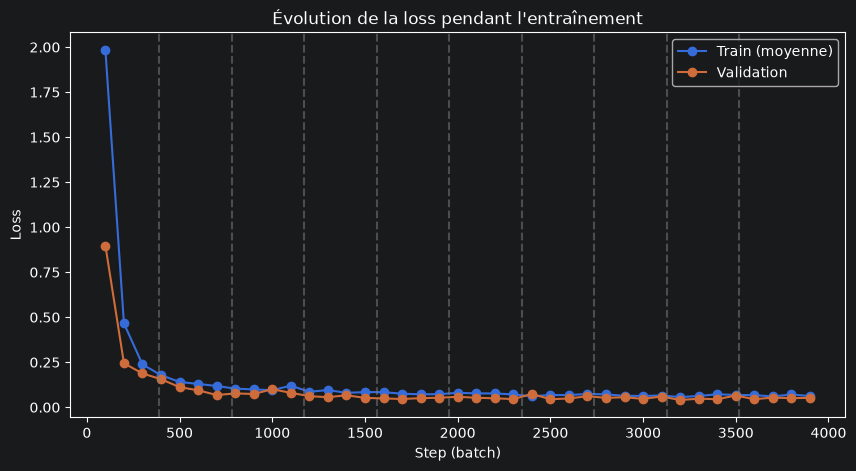

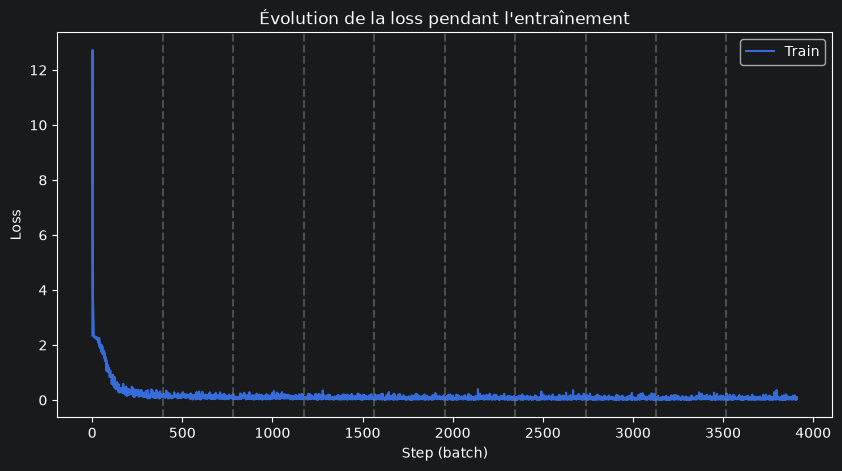

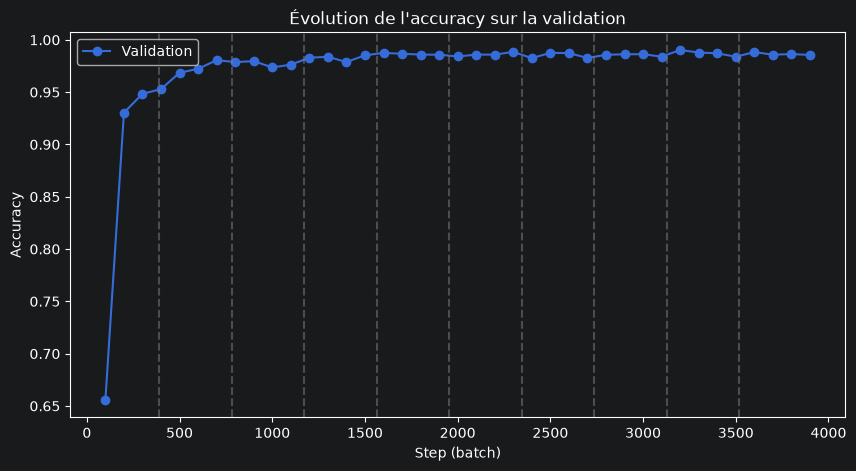

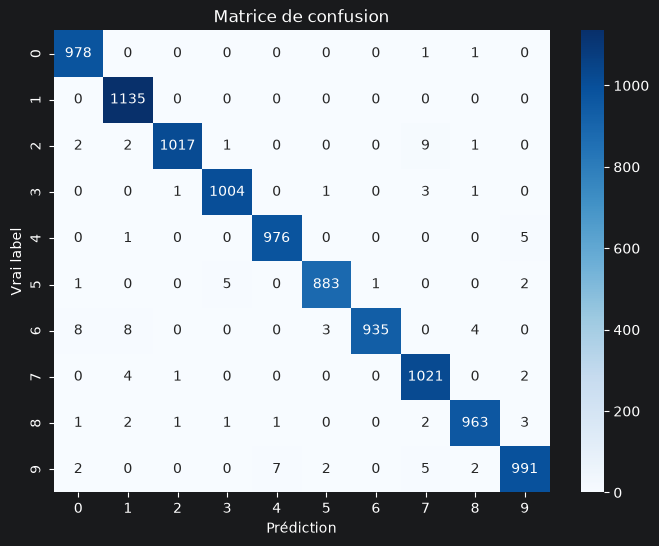

La précision de l'expérience 1 est de:  0.9902999997138977


In [62]:
# 2. Varier le taux d'apprentissage, taux de dropout
experience_2_batch_size = 128
conv_bloc_4 = ConvolutionBlock(
    input_shape=(1, 28, 28),
    n_filters=20,
    kernel_size=10,
    use_batch_norm=True,
)
conv_bloc_5 = ConvolutionBlock(
    input_shape=conv_bloc_4.output_shape(),
    n_filters=40,
    kernel_size=10,
    dropout_rate=0.5,
    use_batch_norm=True,
)
conv_bloc_6 = ConvolutionBlock(
    input_shape=conv_bloc_5.output_shape(),
    n_filters=60,
    kernel_size=10,
    dropout_rate=0.5,
    use_batch_norm=True,
)

experience_2 = ExperimentalCNN(
    convolutions=nn.ModuleList([conv_bloc_4, conv_bloc_5, conv_bloc_6]),
    n_neural_layer=300,
    n_labels=len(train.targets.unique()),
    learning_rate=2*10e-3
)

experience_2.show_summary()
experience_2.fit(
    train_data=train,
    epochs=10,
    batch_size=experience_2_batch_size,
    validation_data=validation,
    eval_every=100,
)
experience_2.plot_loss()
experience_2.plot_loss(show_validation=False)
experience_2.plot_accuracy()
experience_2.score(test, batch_size=experience_2_batch_size, scoring="confusion_matrix")
print(f"La précision de l'expérience 1 est de: ", experience_2.score(test, batch_size=experience_2_batch_size, scoring="accuracy"))

### Comparaisons des différents modèles et identification des architectures avec les meilleurs résultats

Nous avons mené notre étude sur 3 modèles :
* un CNN basique avec une couche de convolution dont le filtre est de taille 5*5, un padding same, un stride 1 avec un MaxPooling de kernel 2*2, padding 0 et stride 2.
* Un 1er modèle expérimental possédant 3 couches de convolution de noyau de taille 3*3, padding same, stride 1, avec à leur sortie chacune une couche de batch normalization, un dropout de 0,2 à la sortie des deux dernières couches de convolution. Le taux d'apprentissage fixé à $10^{-3}
* Un 2er modèle expérimental possédant 3 couches de convolution de noyau de taille 3*3, padding same, stride 1, avec à leur sortie chacune une couche de batch normalization, un dropout de 0,2 à la sortie des deux dernières couches de convolution. Le taux d'apprentissage fixé à $10^{-3}